# KDEllipsPy: Synthetic Simulation Example for Google Colab

This notebook demonstrates how to run a synthetic earthquake simulation using the Axitra forward engine with an elliptical slip patch distribution.

### 1. Installation

We clone the repository and install the dependencies. **Crucial:** We must ensure NumPy < 2.0.0 and SciPy < 1.14.0 are used to maintain compatibility with the Python 3.12 environment in Colab.

In [ ]:
!git clone https://github.com/alexvillarroel/KDEllipsPy.git
%cd KDEllipsPy

# 2. Uninstall conflicting versions
!pip uninstall -y numpy scipy

# 3. Install stable dependencies and build tools
!pip install "numpy>=1.26.4,<2.0.0" "scipy<1.14.0" meson ninja pyproj obspy neighpy pymc arviz --quiet

# 4. Install KDEllipsPy python package
!pip install -e .

# 5. Manually compile the Axitra Fortran binaries
!cd kdellipspy/axitra/src && make clean && make all && make python PYTHON=python3

**Note:** If Colab asks you to "Restart Session" after installation, please do so before continuing.

### 2. Imports and Configuration

We load the configuration from an `input.ctl` file. This file contains the velocity model, station locations, and fault plane parameters.

Loaded configuration: Calama 2020 Intraplate
Stations: 8


/home/alex/micromamba/envs/seismology/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


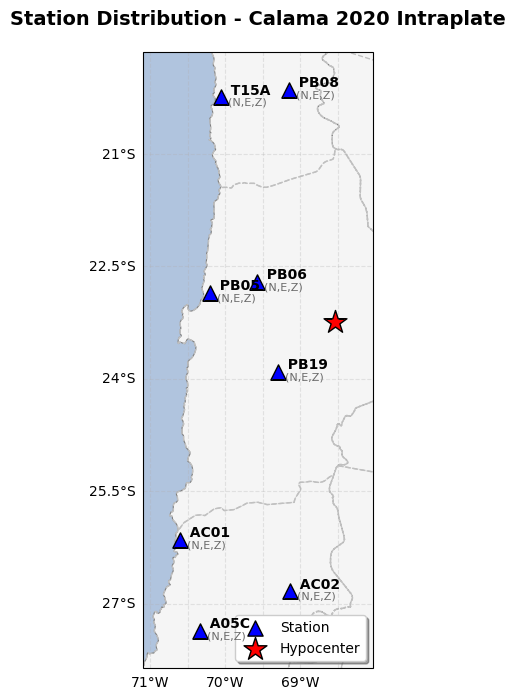

(<Figure size 1000x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Station Distribution - Calama 2020 Intraplate'}>)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from kdellipspy import ConfigParser, AxitraForwardModel
from pathlib import Path

# Use an existing example configuration
input_file = "inversions/calama2020/input.ctl"
cfg = ConfigParser(input_file)

print(f"Loaded configuration: {cfg.source_position.event_name}")
print(f"Stations: {len(cfg.stations.stations)}")

# Plot station map directly from config
cfg.plot_stations()

### 3. Define the Elliptical Slip Model

The elliptical model is defined by 7 parameters:
1. `a1`: Semi-axis 1 (km)
2. `a2`: Semi-axis 2 (km)
3. `theta`: Rotation angle (fraction of $\pi$)
4. `np`: Position fraction [0, 1] relative to center
5. `tp`: Position angle (fraction of $2\pi$)
6. `dmax`: Maximum slip (meters)
7. `vr`: Rupture velocity (km/s)

Initializing Forward Model...
1. Building geometry...
2. Visualizing Slip distribution...


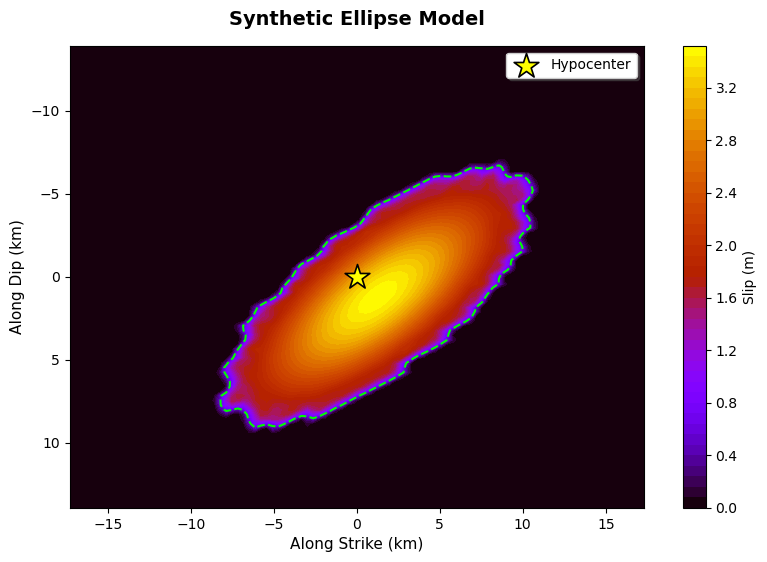

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Synthetic Ellipse Model'}, xlabel='Along Strike (km)', ylabel='Along Dip (km)'>)

In [6]:
# Model parameters: [a1_km, a2_km, theta_pi, np, tp_2pi, dmax_m, vr_kms]
model_params = np.array([12.0, 8.0, 0.2, 0.4, 0.3, 3.5, 2.8])

print("Initializing Forward Model...")
fm = AxitraForwardModel(input_file)

print("1. Building geometry...")
geom = fm.build_geometry_with_ellipse_slip(model_params)

print("2. Visualizing Slip distribution...")
geom.plot(title="Synthetic Ellipse Model")

### 4. Run Forward Simulation

Now we run the Axitra engine to compute Green's functions and convolve them with the source time function.

In [7]:
print("1. Computing Green's Functions (Axitra)... ")
ap = fm.build_axitra(geom)
ap = fm.green(ap, quiet=True)

print("2. Convolving with source function...")
# source_type=1 (Ricker wavelet), unit=1 (Displacement)
time, sx, sy, sz = fm.conv(ap, geom, source_type=1, unit=1, quiet=True)

print("Done!")
print(f"Synthetics generated for {sx.shape[0]} stations.")

1. Computing Green's Functions (Axitra)... 
2. Convolving with source function...
Done!
Synthetics generated for 8 stations.


### 5. Plot Synthetic Seismograms

We plot the North, East, and Vertical components for all stations using the general plotting utility.

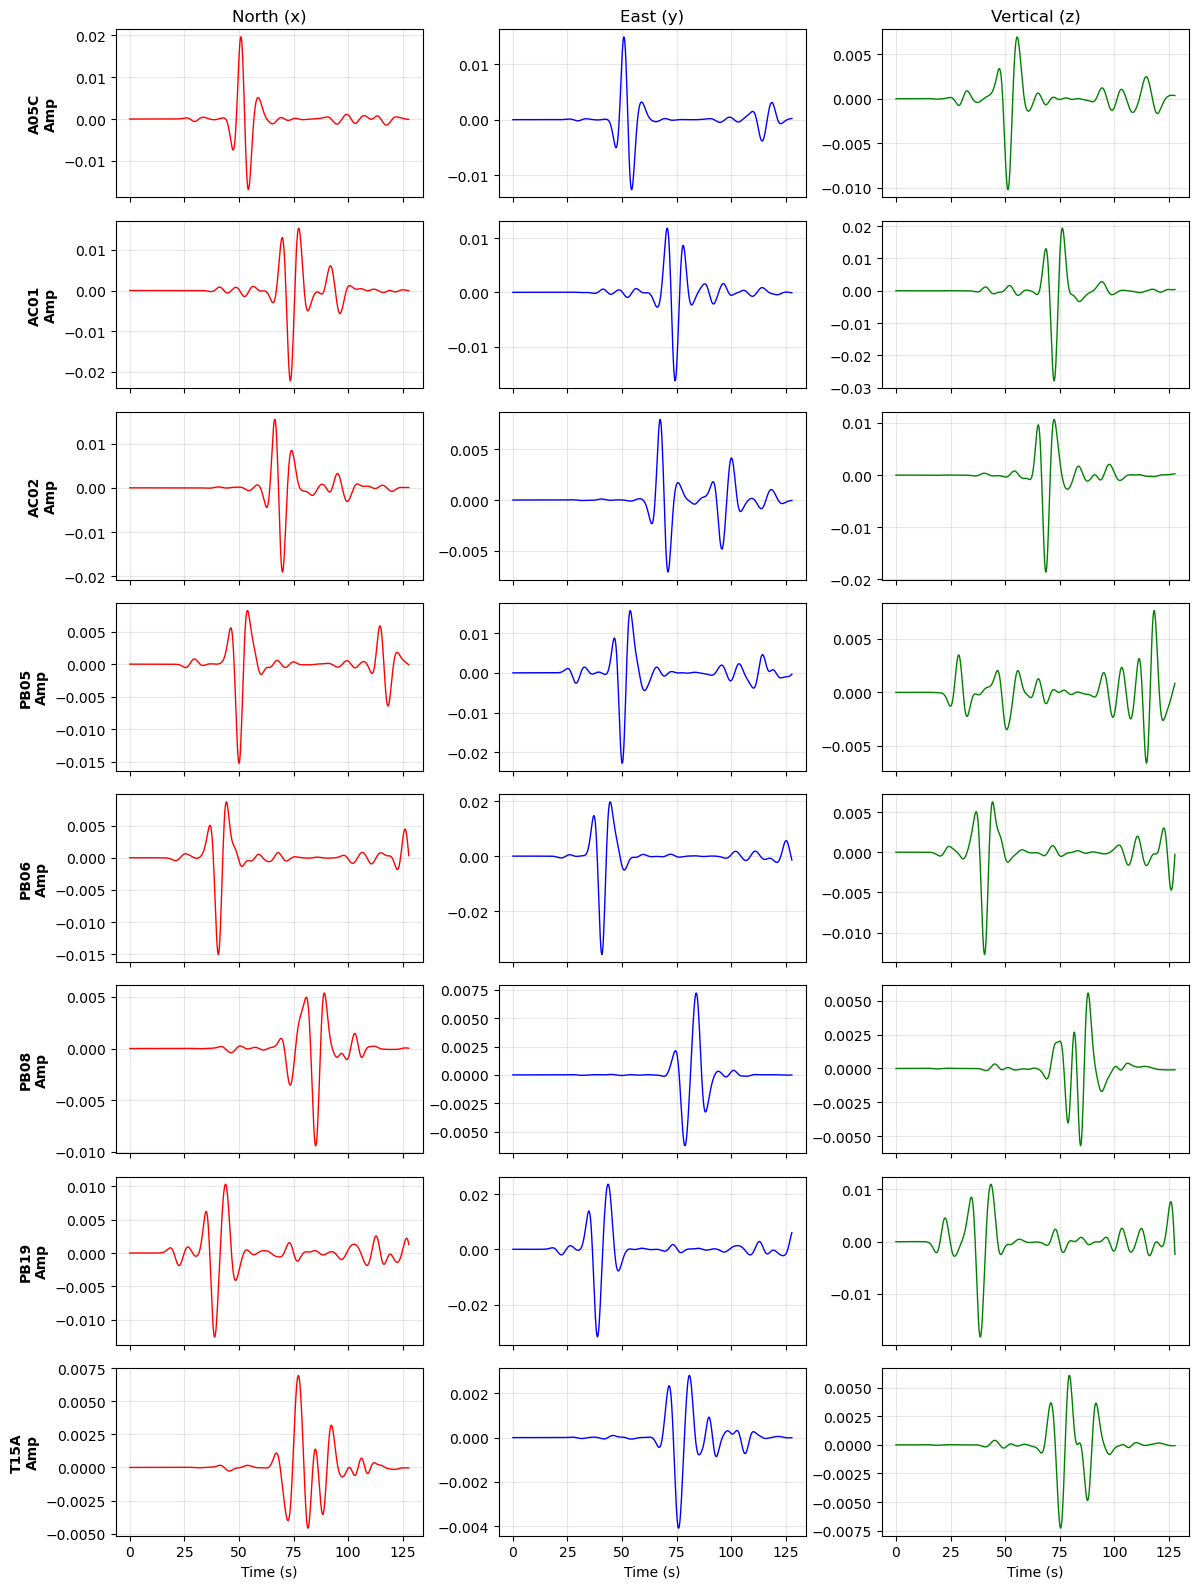

(<Figure size 1200x1600 with 24 Axes>,
 array([[<Axes: title={'center': 'North (x)'}, ylabel='A05C\nAmp'>,
         <Axes: title={'center': 'East (y)'}>,
         <Axes: title={'center': 'Vertical (z)'}>],
        [<Axes: ylabel='AC01\nAmp'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='AC02\nAmp'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='PB05\nAmp'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='PB06\nAmp'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='PB08\nAmp'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='PB19\nAmp'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='Time (s)', ylabel='T15A\nAmp'>,
         <Axes: xlabel='Time (s)'>, <Axes: xlabel='Time (s)'>]],
       dtype=object))

In [8]:
from kdellipspy import plotting

station_names = [s.name for s in cfg.stations.stations]
synthetics = np.array([sx, sy, sz]).transpose(1, 0, 2)

plotting.plot_synthetic_components(time, synthetics, station_names)